#**Estadística descriptiva e histogramas**

La estadística descriptiva es el primer paso en cualquier análisis de datos, ya que permite resumir, organizar y entender la información de manera general antes de aplicar métodos más complejos. Su objetivo principal es describir las características más importantes de los datos mediante medidas como la media, la mediana, la desviación estándar, los valores mínimos y máximos, entre otros.
Sin embargo, las medidas numéricas por sí solas no siempre son suficientes para comprender completamente los datos. Por ello, es fundamental complementarlas con herramientas visuales, como los histogramas, que permiten observar la distribución de una variable de forma gráfica.
El histograma es especialmente útil cuando se trabaja con variables numéricas, ya que agrupa los valores en intervalos y muestra cuántas observaciones caen en cada uno. Esto facilita la identificación de patrones, como la concentración de valores en ciertos rangos, la presencia de asimetría o la existencia de valores atípicos.
En el contexto clínico, combinar estadística descriptiva con histogramas permite tener una visión más completa de los datos. Por ejemplo, mientras que un promedio puede indicar el nivel general de glucosa en una población, el histograma puede revelar si existen muchos pacientes con valores elevados o si la distribución es desigual.

In [3]:

install.packages("tidyverse")
install.packages("janitor")
install.packages("gtsummary")


library(tidyverse)
library(janitor)
library(gtsummary)

datos <- read_csv("data/datos_medicos.csv") %>%
  clean_names() %>%
  mutate(
    sexo = factor(sexo),
    grupo = factor(grupo),
    fumador = factor(fumador),
    diabetes = factor(diabetes, levels = c(0, 1), labels = c("No", "Sí")),
    hipertension = factor(hipertension, levels = c(0, 1), labels = c("No", "Sí")),
    evento_complicacion = factor(evento_complicacion, levels = c(0, 1), labels = c("No", "Sí")),
    cambio_hb = hb_post - hb_pre
  )

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘snakecase’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘V8’, ‘litedown’, ‘reactR’, ‘bigD’, ‘bitops’, ‘juicyjuice’, ‘markdown’, ‘reactable’, ‘cards’, ‘cardx’, ‘gt’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘janitor’


The fol

In [4]:
# ----------------------------------------------------------
# 1. Descriptivos básicos
# ----------------------------------------------------------

mean(datos$edad, na.rm = TRUE)
sd(datos$edad, na.rm = TRUE)
median(datos$edad, na.rm = TRUE)
quantile(datos$edad, probs = c(0.25, 0.75), na.rm = TRUE)
range(datos$edad, na.rm = TRUE)

[1] 51.16364

[1] 14.1457

[1] 51

25% 75% 
 42  61

[1] 18 88

In [5]:
# ----------------------------------------------------------
# 2. Función útil para resumir variable numérica
# ----------------------------------------------------------

resumen_numerico <- function(x) {
  tibble(
    n = sum(!is.na(x)),
    media = mean(x, na.rm = TRUE),
    de = sd(x, na.rm = TRUE),
    mediana = median(x, na.rm = TRUE),
    q1 = quantile(x, 0.25, na.rm = TRUE),
    q3 = quantile(x, 0.75, na.rm = TRUE),
    minimo = min(x, na.rm = TRUE),
    maximo = max(x, na.rm = TRUE)
  )
}

resumen_numerico(datos$glucosa_mg_dl)

n,media,de,mediana,q1,q3,minimo,maximo
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
215,119.7047,25.6126,122,99.75,139.45,66.6,175.6


In [6]:
# ----------------------------------------------------------
# 3. Descriptivos por grupo
# ----------------------------------------------------------

datos %>%
  group_by(grupo) %>%
  summarise(
    n = n(),
    edad_media = mean(edad, na.rm = TRUE),
    edad_de = sd(edad, na.rm = TRUE),
    glucosa_mediana = median(glucosa_mg_dl, na.rm = TRUE),
    glucosa_q1 = quantile(glucosa_mg_dl, 0.25, na.rm = TRUE),
    glucosa_q3 = quantile(glucosa_mg_dl, 0.75, na.rm = TRUE),
    complicaciones = sum(evento_complicacion == "Sí", na.rm = TRUE),
    prop_complicaciones = mean(evento_complicacion == "Sí", na.rm = TRUE)
  )

grupo,n,edad_media,edad_de,glucosa_mediana,glucosa_q1,glucosa_q3,complicaciones,prop_complicaciones
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
Control,81,49.19753,13.85588,126.9,105.7,140.2,15,0.1851852
Tratamiento_A,71,52.76056,13.82902,119.6,100.3,137.5,12,0.1690141
Tratamiento_B,68,51.83824,14.73711,118.9,95.4,142.7,13,0.1911765


In [11]:
# ----------------------------------------------------------
# 4. Variables categóricas: frecuencias y porcentajes
# ----------------------------------------------------------

tabyl(datos, diabetes)
tabyl(datos, grupo, diabetes) %>%
  adorn_percentages("row") %>%
  adorn_pct_formatting(digits = 1)

diabetes,n,percent
<fct>,<int>,<dbl>
No,106,0.4818182
Sí,114,0.5181818


grupo,No,Sí
<fct>,<chr>,<chr>
Control,49.4%,50.6%
Tratamiento_A,43.7%,56.3%
Tratamiento_B,51.5%,48.5%


In [10]:
# ----------------------------------------------------------
# 5. Tabla clínica tipo "Tabla 1"
# ----------------------------------------------------------

tabla_1 <- datos %>%
  select(edad, sexo, grupo, imc, diabetes, hipertension, glucosa_mg_dl, evento_complicacion) %>%
  tbl_summary(
    by = grupo,
    statistic = list(
      all_continuous() ~ "{mean} ± {sd}",
      all_categorical() ~ "{n} ({p}%)"
    ),
    missing = "ifany"
  ) %>%
  add_overall() %>%
  add_p()

tabla_1

<div id="tlfliyxbgw" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#tlfliyxbgw table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#tlfliyxbgw thead, #tlfliyxbgw tbody, #tlfliyxbgw tfoot, #tlfliyxbgw tr, #tlfliyxbgw td, #tlfliyxbgw th {
  border-style: none;
}

#tlfliyxbgw p {
  margin: 0;
  padding: 0;
}

#tlfliyxbgw .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  b

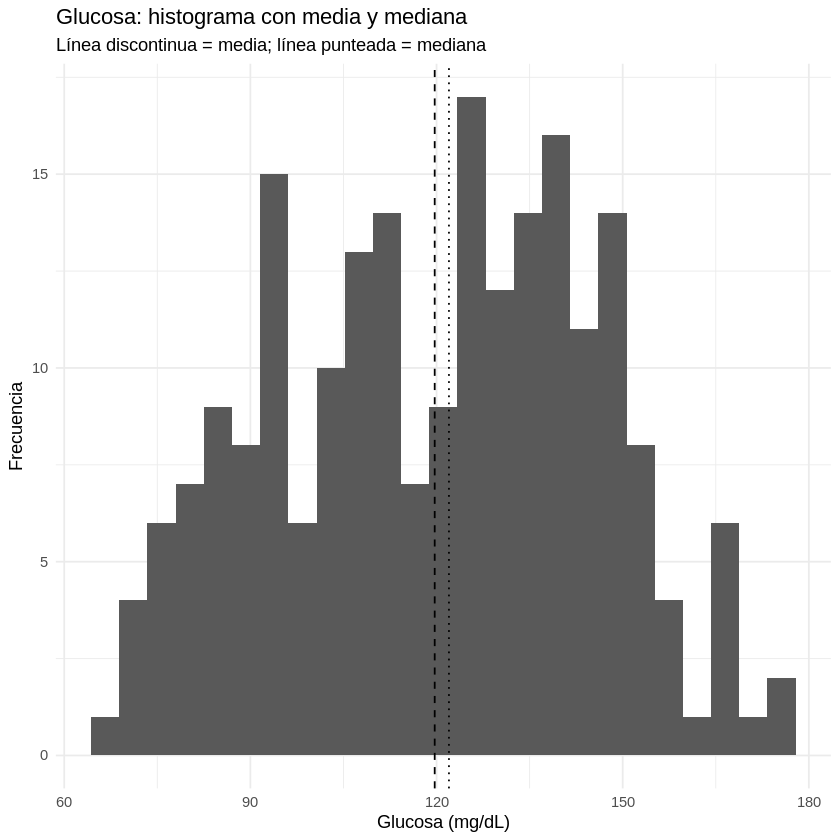

In [12]:
# ----------------------------------------------------------
# 6. Histograma con línea de media y mediana
# ----------------------------------------------------------

media_glucosa <- mean(datos$glucosa_mg_dl, na.rm = TRUE)
mediana_glucosa <- median(datos$glucosa_mg_dl, na.rm = TRUE)

ggplot(datos, aes(x = glucosa_mg_dl)) +
  geom_histogram(bins = 25, na.rm = TRUE) +
  geom_vline(xintercept = media_glucosa, linetype = "dashed") +
  geom_vline(xintercept = mediana_glucosa, linetype = "dotted") +
  labs(
    title = "Glucosa: histograma con media y mediana",
    subtitle = "Línea discontinua = media; línea punteada = mediana",
    x = "Glucosa (mg/dL)",
    y = "Frecuencia"
  ) +
  theme_minimal()

#**Ejercicios**


**Ejercicio 1:**
 Calcular media ± DE y mediana [Q1, Q3] de colesterol_mg_dl.

**Ejercicio 2:**
Calcular frecuencia de hipertensión por sexo.

**Ejercicio 3:**
Crear una tabla 1 comparando por evento_complicacion.
